In [23]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from ITIS_Model_funcs import get_nominal_param,OLS_res,ITIS

In [24]:
param_log,IC = get_nominal_param()
IC = [ 2.0,          0.,          0.14759607,  0.,         13.75484703,  3.13344442, 15.73028492,  1.38649737]

D = '3'         # '1' for ACTH + Cort,
                # '2' for ACTH + Cort + TNF-a
                # '3' for ACTH + Cort + TNF-a + IL10
dpoints = '2'   # '1' for 25, '2' for 13

if D == '1':
    output_ids = [6,7]
elif D == '2':
    output_ids = [3,6,7]
else:
    output_ids = [3,4,6,7]

with open('syntheticData\\TRUE_SOL' + D + dpoints + '.pkl', 'rb') as f:
    results = pickle.load(f)

t_data = results['t_data']
y_data = results['y_data']

##SENSITIVITY ANALYSIS
h = 1e-6  #amount to perturb parameters
n_param = len(param_log)
n_states = len(output_ids)

S = np.zeros((n_param, len(t_data) * n_states)) ##Initialize shape of sensitivity matrix.

for i in range(n_param):  #calculate the relative residual sensitivity to each 45 parameters

        param_in = param_log[i]
        param_delta = param_in + h
##RIGHT NOW THIS IS BEING CALCULATED WITH NOISELESS DATA
        S[i, :] = ((1 / h) * (OLS_res(param_delta, y_data, t_data, i, output_ids, param_log, IC)
                                            - OLS_res(param_in, y_data, t_data, i, output_ids, param_log, IC)))

In [25]:
##import rankings from global analysis
with open('paramRankings\\rankingDesign' + D + '.pkl', 'rb') as f:
    results = pickle.load(f)

rank_value = results['rank_value']      # sorted ranking values
param_sorted = results['param_sorted']  #accordingly sorted params as strings
rank_cut = np.array(rank_value)[np.array(rank_value) > .25 * np.array(rank_value)[0]]
param_sorted = np.array(param_sorted)[:len(rank_cut)]

param_titles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

circadian_param = ['alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc'] #exclude?

cond = 0
unid = []
p_indices = [param_titles.index(param_sorted[0])]
for i in range(1,len(rank_cut)):
    p_indices.append(param_titles.index(param_sorted[i]))
    S_opt = S[p_indices,:].copy()
    F_opt = S_opt@S_opt.T
    cond = np.linalg.cond(F_opt)
    if cond > 1e+6:
        unid.append(p_indices.pop())
        print("Removed: ", unid[-1])


S_opt = S[p_indices,:].copy()
F_opt = S_opt@S_opt.T
C_opt = np.linalg.inv(F_opt)
selected = [param_titles[i] for i in p_indices]
print("Design : ", D + dpoints)
print("Number of selected parameters:", len(p_indices))
print("Selected Parameters: ",  selected)
print(p_indices)
print("Excluded Parameters: ", [param_titles[i] for i in unid])
print("Condition Number of F:", np.linalg.cond(F_opt))
print("Diagonals of C:", np.diag(C_opt))

Design :  32
Number of selected parameters: 16
Selected Parameters:  ['h6', 'd7', 'd4', 'k3', 'T', 'd8', 'beta', 'h7', 'h11', 'k14', 'k4', 'h9', 'h4', 'k6', 'd3', 'k15']
[12, 33, 16, 7, 43, 36, 39, 15, 32, 31, 8, 21, 9, 14, 10, 34]
Excluded Parameters:  []
Condition Number of F: 11953.795746044832
Diagonals of C: [0.19510513 0.22827239 0.51252179 0.18506776 0.53480163 0.48511877
 2.29638398 0.1962738  0.20991786 0.14695226 0.21570837 0.03365302
 0.61363941 1.39143883 0.09685494 0.25256615]


<BarContainer object of 16 artists>

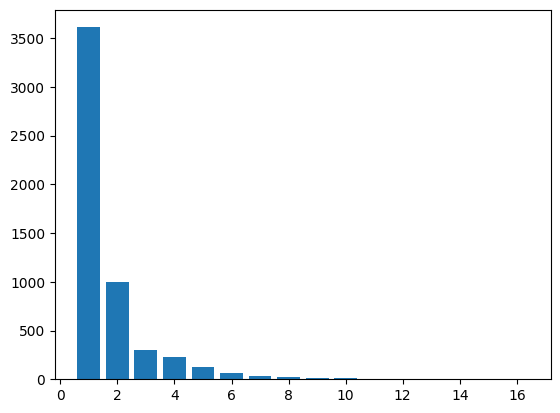

In [26]:
F_eigen = np.linalg.eigvals(F_opt)
plt.figure()
plt.bar(np.linspace(1,len(p_indices),len(p_indices)),F_eigen)


<BarContainer object of 16 artists>

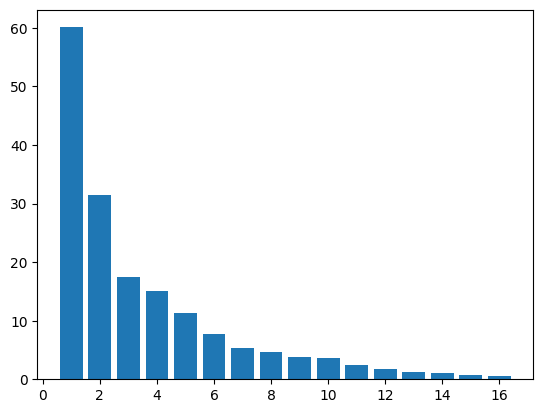

In [27]:
U, S_svd, V = np.linalg.svd(S_opt)
plt.figure()
plt.bar(np.linspace(1,len(p_indices),len(p_indices)), S_svd)

In [28]:
#Complete F
F = S@S.T
C = np.linalg.inv(F)
print("Condition Number of F:", np.linalg.cond(F))
print(np.linalg.matrix_rank(F))
print("Diagonals of F:", np.diag(F))
print("Diagonals of C:", np.diag(C))
diag = np.diag(C)
unid = [param_titles[i] for i in list(np.where(diag > 1e+3))[0]]
print("Unidentifiable:", unid) ##this isn't really useful right now

Condition Number of F: 6.86927515945057e+17
44
Diagonals of F: [1.45187697e+01 4.97525841e+01 2.82731030e+01 8.02397379e+02
 7.04843724e+02 6.90375422e+02 9.86391091e+02 1.98790366e+02
 3.49207776e+02 6.16286742e+01 5.63979761e+02 3.64731989e+02
 3.88003270e+02 2.67967389e+01 3.86810026e+01 4.66823528e+02
 4.25997133e+02 3.98395550e+02 2.50594300e+01 4.09814651e+02
 4.09873835e+02 4.26654758e+02 6.68527610e+01 6.42315134e+02
 4.93445500e-04 6.58267789e+01 1.07237579e+01 6.64584092e+02
 5.23978281e+01 7.69304202e+02 5.77188947e+02 5.69625051e+02
 4.34592441e+02 2.63713564e+02 6.94954733e+02 3.53555037e+01
 1.94643358e+02 1.01107861e+01 9.10176720e-01 8.38127840e+01
 2.95342063e+00 6.64178995e+01 4.96941453e-01 2.59258512e+02
 1.07296348e+01]
Diagonals of C: [1.27006549e+05 6.96421569e+04 3.32072786e+07 5.08847114e+04
 2.04011443e+04 6.66447960e+03 2.60563720e+03 2.02264760e+05
 2.75745345e+04 1.28593450e+06 7.87970470e+03 8.35265200e+03
 4.61766186e+04 1.60422415e+07 1.92347817e+06 1.61

In [29]:
##SAVE FUNCTIONALITY

# all_results = {
#     'S': S,
#     'S_opt': S_opt,
# }
#
# with open('Sensitivities\\sens' + D + dpoints + '.pkl', 'wb') as f:
#     pickle.dump(all_results, f)